# MSK Problem A - Binary Classification
## Normal vs Affected (Disease)

**Task:** Classify ultrasound images as:
- **Normal (N)** → Label 0
- **Affected (D/P/I)** → Label 1

**Model:** ResNet50 with transfer learning

**Metrics:** Accuracy, AUC, Precision, Recall

## Step 1: Mount Google Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Step 2: Set Your Paths
⚠️ **IMPORTANT:** Change `BASE_DIR` to match your Google Drive path!

In [2]:
import os

# ⚠️ CHANGE THIS TO YOUR DRIVE PATH
BASE_DIR = "/content/drive/MyDrive/MSK project"

EXCEL_PATH = os.path.join(BASE_DIR, "PatientImages_MATCHED.xlsx")
IMG_DIR = os.path.join(BASE_DIR, "processed_images")
RESULTS_DIR = os.path.join(BASE_DIR, "results_A")

os.makedirs(RESULTS_DIR, exist_ok=True)

# Verify paths exist
print("Checking paths...")
print(f"  Base dir exists: {os.path.exists(BASE_DIR)}")
print(f"  Excel file exists: {os.path.exists(EXCEL_PATH)}")
print(f"  Images dir exists: {os.path.exists(IMG_DIR)}")

if os.path.exists(IMG_DIR):
    imgs = os.listdir(IMG_DIR)
    print(f"  Number of images: {len(imgs)}")

Checking paths...
  Base dir exists: True
  Excel file exists: True
  Images dir exists: True
  Number of images: 3214


## Step 3: Import Libraries

In [3]:
import cv2
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc

from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Input, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint, CSVLogger

print("✅ All libraries imported successfully!")
print(f"TensorFlow version: {tf.__version__}")
print(f"GPU available: {tf.config.list_physical_devices('GPU')}")

✅ All libraries imported successfully!
TensorFlow version: 2.19.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## Step 4: Configuration

In [4]:
IMG_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 20

UNFREEZE_LAYERS = 100
LEARNING_RATE = 1e-5

MODEL_OUT = os.path.join(RESULTS_DIR, "ResNet50_ProblemA_best.keras")

tf.random.set_seed(42)
np.random.seed(42)

print("✅ Configuration set!")
print(f"   Image Size: {IMG_SIZE}")
print(f"   Batch Size: {BATCH_SIZE}")
print(f"   Epochs: {EPOCHS}")
print(f"   Learning Rate: {LEARNING_RATE}")
print(f"   Unfreeze Layers: {UNFREEZE_LAYERS}")

✅ Configuration set!
   Image Size: 224
   Batch Size: 32
   Epochs: 20
   Learning Rate: 1e-05
   Unfreeze Layers: 100


## Step 5: Load and Prepare Data

In [5]:
# Load Excel file
df = pd.read_excel(EXCEL_PATH)

# Find diagnosis column
diag_col = [c for c in df.columns if "diagn" in c.lower()][0]
print(f"✅ Diagnosis column: {diag_col}")

# Clean diagnosis
df["Diagnosis_Clean"] = df[diag_col].astype(str).str.strip()

# Create binary labels: Normal (0) vs Affected (1)
def label_A(diag):
    return 0 if diag == "N" else 1

df["label_A"] = df["Diagnosis_Clean"].apply(label_A)

# Verify filename column exists
if "filename" not in df.columns:
    raise ValueError("Expected a 'filename' column in the Excel file.")

df = df.dropna(subset=["filename"]).copy()

print("\n📊 Class Distribution:")
print(f"   Normal (0): {(df['label_A'] == 0).sum()}")
print(f"   Affected (1): {(df['label_A'] == 1).sum()}")

✅ Diagnosis column: Diagnosis
D - Dermatomyositis
P - Polymyositis
I - IBM
N - normal

📊 Class Distribution:
   Normal (0): 1313
   Affected (1): 1901


## Step 6: Split Data

In [6]:
# Stratified split: 70% train, 15% val, 15% test
train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    random_state=42,
    stratify=df["label_A"]
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=42,
    stratify=temp_df["label_A"]
)

# Save splits
train_df.to_csv(os.path.join(RESULTS_DIR, "train_A.csv"), index=False)
val_df.to_csv(os.path.join(RESULTS_DIR, "val_A.csv"), index=False)
test_df.to_csv(os.path.join(RESULTS_DIR, "test_A.csv"), index=False)

print(f"📂 Data Split:")
print(f"   Train: {len(train_df)}")
print(f"   Validation: {len(val_df)}")
print(f"   Test: {len(test_df)}")

📂 Data Split:
   Train: 2249
   Validation: 482
   Test: 483


## Step 7: Compute Class Weights

In [7]:
classes = np.array([0, 1])
cw = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=train_df["label_A"].values
)
class_weight = {0: float(cw[0]), 1: float(cw[1])}
print(f"⚖️ Class weights: {class_weight}")

⚖️ Class weights: {0: 1.2236126224156691, 1: 0.8454887218045113}


## Step 8: Create Data Pipeline

In [8]:
def load_image(filename, label):
    """Load and preprocess image."""
    file = filename.decode("utf-8") if isinstance(filename, (bytes, bytearray)) else str(filename)
    path = os.path.join(IMG_DIR, file)

    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)

    # Handle missing/corrupt images
    if img is None:
        img = np.zeros((IMG_SIZE, IMG_SIZE), dtype=np.uint8)

    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_AREA)

    # Grayscale -> 3 channels
    img = np.stack([img, img, img], axis=-1).astype("float32")

    # Normalize to [0, 1]
    img = img / 255.0

    return img, np.int32(label)


def df_to_dataset(dataframe, batch_size=32, shuffle=True):
    """Convert dataframe to tf.data.Dataset."""
    filenames = dataframe["filename"].astype(str).values
    labels = dataframe["label_A"].values.astype("int32")

    ds = tf.data.Dataset.from_tensor_slices((filenames, labels))

    def load_and_fix_shape(x, y):
        img, lbl = tf.numpy_function(load_image, [x, y], [tf.float32, tf.int32])
        img.set_shape((IMG_SIZE, IMG_SIZE, 3))
        lbl.set_shape(())
        return img, lbl

    ds = ds.map(load_and_fix_shape, num_parallel_calls=tf.data.AUTOTUNE)

    if shuffle:
        ds = ds.shuffle(800, reshuffle_each_iteration=True)

    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds


# Create datasets
train_ds = df_to_dataset(train_df, batch_size=BATCH_SIZE, shuffle=True)
val_ds = df_to_dataset(val_df, batch_size=BATCH_SIZE, shuffle=False)
test_ds = df_to_dataset(test_df, batch_size=BATCH_SIZE, shuffle=False)

print("✅ Data pipeline ready!")

✅ Data pipeline ready!


## Step 9: Data Augmentation

In [9]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomContrast(0.2),
    tf.keras.layers.RandomZoom(0.1)
], name="data_augmentation")

print("✅ Data augmentation configured!")

✅ Data augmentation configured!


## Step 10: Build ResNet50 Model

In [10]:
# Input layer
inputs = Input(shape=(IMG_SIZE, IMG_SIZE, 3))

# Apply augmentation
x = data_augmentation(inputs)

# Load pre-trained ResNet50
base = ResNet50(
    weights="imagenet",
    include_top=False,
    input_tensor=x
)

# Freeze all layers first
for layer in base.layers:
    layer.trainable = False

# Unfreeze last N layers for fine-tuning
for layer in base.layers[-UNFREEZE_LAYERS:]:
    layer.trainable = True

# Classification head
x = GlobalAveragePooling2D()(base.output)
x = Dense(256, activation="relu")(x)
x = Dropout(0.3)(x)
outputs = Dense(1, activation="sigmoid")(x)  # Binary classification

# Create model
model = Model(inputs, outputs)

# Compile with binary crossentropy
model.compile(
    optimizer=Adam(LEARNING_RATE),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.AUC(name="auc"),
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall"),
    ]
)

print(f"\n✅ Model built!")
print(f"   Trainable ResNet layers: {sum(l.trainable for l in base.layers)} / {len(base.layers)}")
print(f"   Best model will be saved to: {MODEL_OUT}")

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step

✅ Model built!
   Trainable ResNet layers: 100 / 176
   Best model will be saved to: /content/drive/MyDrive/MSK project/results_A/ResNet50_ProblemA_best.keras


## Step 11: Setup Callbacks

In [11]:
callbacks = [
    ModelCheckpoint(
        MODEL_OUT,
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    ),
    EarlyStopping(
        monitor="val_loss",
        patience=8,
        restore_best_weights=True
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.3,
        patience=3,
        min_lr=1e-7,
        verbose=1
    ),
    CSVLogger(os.path.join(RESULTS_DIR, "training_log_A.csv"))
]

print("✅ Callbacks configured!")

✅ Callbacks configured!


## Step 12: Train Model 🚀

In [12]:
print("\n" + "="*60)
print("🚀 TRAINING PROBLEM A: Normal vs Affected")
print("="*60)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks,
    class_weight=class_weight
)

print("\n✅ Training complete!")


🚀 TRAINING PROBLEM A: Normal vs Affected
Epoch 1/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 380ms/step - accuracy: 0.4894 - auc: 0.5320 - loss: 0.7564 - precision: 0.5638 - recall: 0.3902
Epoch 1: val_loss improved from inf to 0.97303, saving model to /content/drive/MyDrive/MSK project/results_A/ResNet50_ProblemA_best.keras
71/71 ━━━━━━━━━━━━━━━━━━━━ 162s 536ms/step - accuracy: 0.4902 - auc: 0.5328 - loss: 0.7556 - precision: 0.5650 - recall: 0.3920 - val_accuracy: 0.4087 - val_auc: 0.4484 - val_loss: 0.9730 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 1.0000e-05
Epoch 2/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 364ms/step - accuracy: 0.6587 - auc: 0.7206 - loss: 0.6185 - precision: 0.7425 - recall: 0.6254
Epoch 2: val_loss improved from 0.97303 to 0.68763, saving model to /content/drive/MyDrive/MSK project/results_A/ResNet50_ProblemA_best.keras
71/71 ━━━━━━━━━━━━━━━━━━━━ 42s 464ms/step - accuracy: 0.6587 - auc: 0.7208 - loss: 0.6183 - precision: 0.7427 - recall: 0.6253 - val_ac

## Step 13: Plot Training Curves

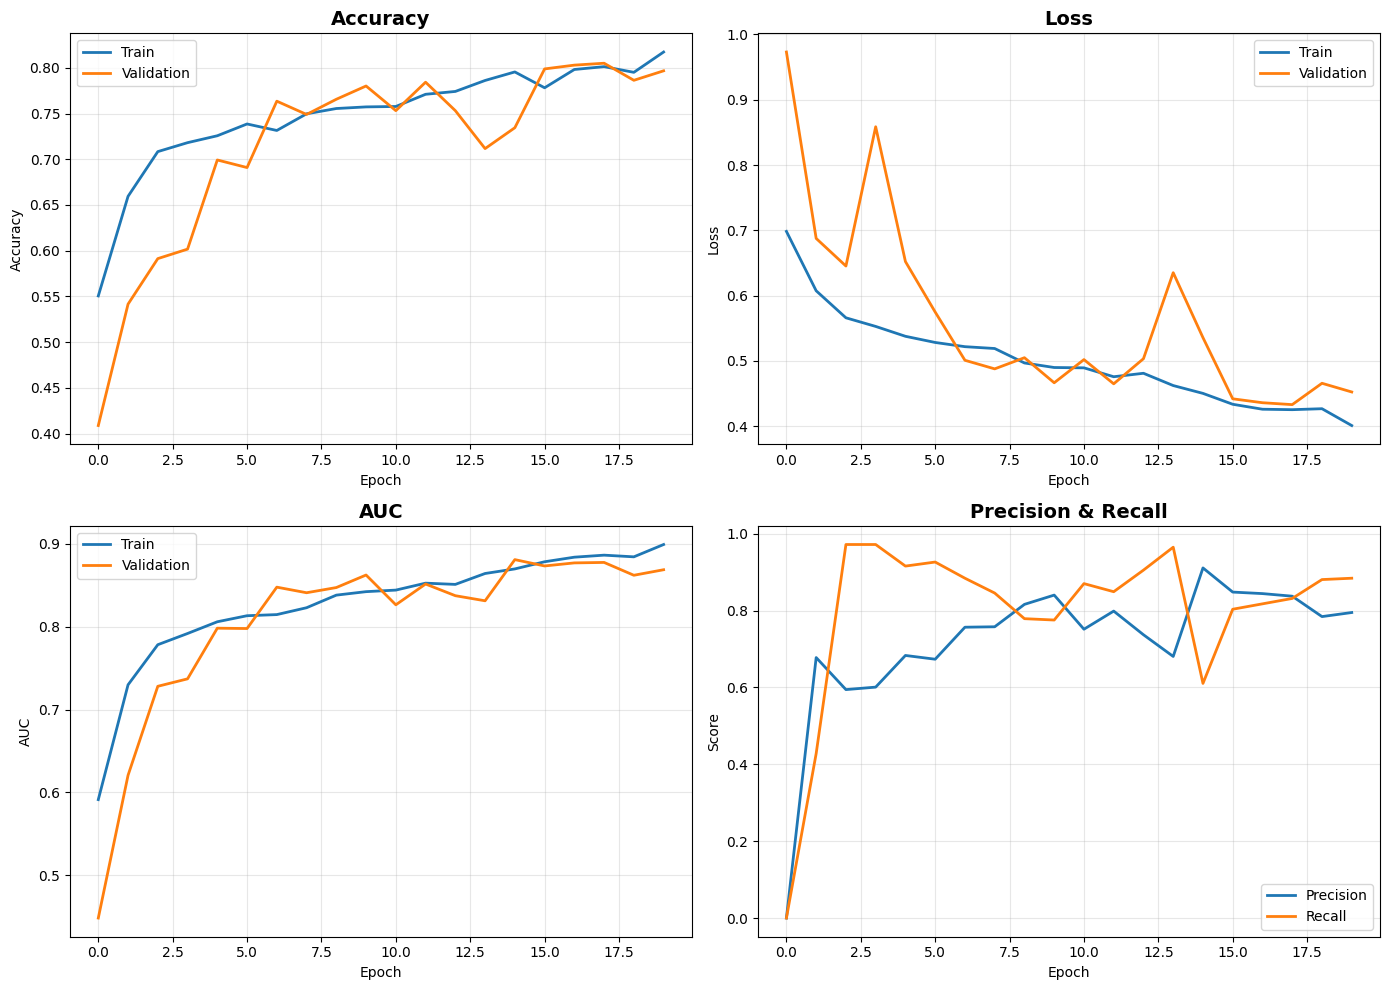

✅ Training curves saved!


In [13]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Accuracy
axes[0, 0].plot(history.history['accuracy'], label='Train', linewidth=2)
axes[0, 0].plot(history.history['val_accuracy'], label='Validation', linewidth=2)
axes[0, 0].set_title('Accuracy', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Accuracy')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Loss
axes[0, 1].plot(history.history['loss'], label='Train', linewidth=2)
axes[0, 1].plot(history.history['val_loss'], label='Validation', linewidth=2)
axes[0, 1].set_title('Loss', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Loss')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# AUC
axes[1, 0].plot(history.history['auc'], label='Train', linewidth=2)
axes[1, 0].plot(history.history['val_auc'], label='Validation', linewidth=2)
axes[1, 0].set_title('AUC', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('AUC')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Precision & Recall
axes[1, 1].plot(history.history['val_precision'], label='Precision', linewidth=2)
axes[1, 1].plot(history.history['val_recall'], label='Recall', linewidth=2)
axes[1, 1].set_title('Precision & Recall', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Score')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "training_curves_A.png"), dpi=150, bbox_inches='tight')
plt.show()

print(f"✅ Training curves saved!")

## Step 14: Print Training Results

In [14]:
print("\n" + "="*60)
print("📊 TRAINING RESULTS")
print("="*60)
print(f"Final Training Accuracy: {history.history['accuracy'][-1]:.4f}")
print(f"Final Training Loss: {history.history['loss'][-1]:.4f}")
print(f"Final Validation Accuracy: {history.history['val_accuracy'][-1]:.4f}")
print(f"Final Validation Loss: {history.history['val_loss'][-1]:.4f}")
print(f"Final Validation AUC: {history.history['val_auc'][-1]:.4f}")
print(f"Final Validation Precision: {history.history['val_precision'][-1]:.4f}")
print(f"Final Validation Recall: {history.history['val_recall'][-1]:.4f}")
print("="*60)


📊 TRAINING RESULTS
Final Training Accuracy: 0.8173
Final Training Loss: 0.4011
Final Validation Accuracy: 0.7967
Final Validation Loss: 0.4525
Final Validation AUC: 0.8688
Final Validation Precision: 0.7950
Final Validation Recall: 0.8842


## Step 15: Test Evaluation

In [15]:
print("\n" + "="*60)
print("🧪 TEST RESULTS")
print("="*60)

test_metrics = model.evaluate(test_ds, verbose=0)
for name, val in zip(model.metrics_names, test_metrics):
    print(f"   {name}: {val:.4f}")

print("="*60)


🧪 TEST RESULTS
   loss: 0.4524
   compile_metrics: 0.7847


## Step 16: Confusion Matrix & Classification Report

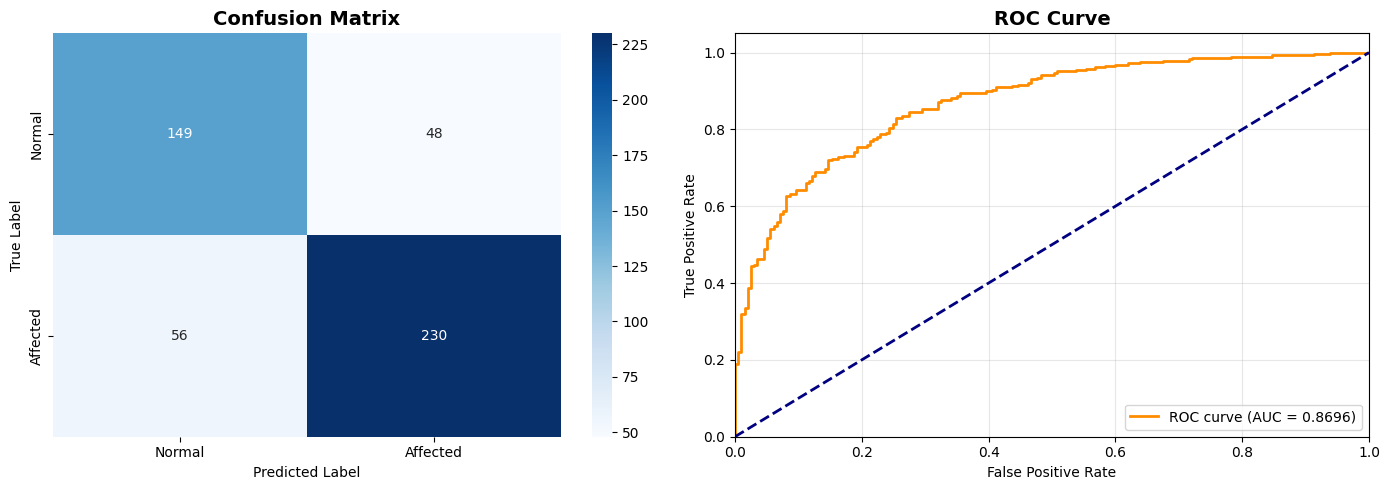


📋 Classification Report:
              precision    recall  f1-score   support

      Normal       0.73      0.76      0.74       197
    Affected       0.83      0.80      0.82       286

    accuracy                           0.78       483
   macro avg       0.78      0.78      0.78       483
weighted avg       0.79      0.78      0.79       483



In [16]:
# Get predictions
y_true = []
y_pred_proba = []

for images, labels in test_ds:
    predictions = model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred_proba.extend(predictions.flatten())

y_true = np.array(y_true)
y_pred_proba = np.array(y_pred_proba)
y_pred = (y_pred_proba >= 0.5).astype(int)

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Normal', 'Affected'], yticklabels=['Normal', 'Affected'])
axes[0].set_title('Confusion Matrix', fontsize=14, fontweight='bold')
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

# ROC Curve
fpr, tpr, _ = roc_curve(y_true, y_pred_proba)
roc_auc = auc(fpr, tpr)

axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve', fontsize=14, fontweight='bold')
axes[1].legend(loc="lower right")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "confusion_matrix_roc_A.png"), dpi=150, bbox_inches='tight')
plt.show()

# Classification Report
print("\n📋 Classification Report:")
print(classification_report(y_true, y_pred, target_names=['Normal', 'Affected']))

## Step 17: Save Final Summary

In [17]:
# Create summary dictionary
summary = {
    "Model": "ResNet50",
    "Problem": "A (Normal vs Affected)",
    "Test_Accuracy": test_metrics[1],
    "Test_AUC": test_metrics[2],
    "Test_Precision": test_metrics[3],
    "Test_Recall": test_metrics[4],
    "Best_Val_Accuracy": max(history.history['val_accuracy']),
    "Best_Val_AUC": max(history.history['val_auc']),
    "Epochs_Trained": len(history.history['accuracy']),
    "Learning_Rate": LEARNING_RATE,
    "Unfreeze_Layers": UNFREEZE_LAYERS
}

# Save to CSV
pd.DataFrame([summary]).to_csv(os.path.join(RESULTS_DIR, "problem_A_summary.csv"), index=False)

print("\n" + "="*60)
print("🎉 PROBLEM A COMPLETE!")
print("="*60)
print(f"\n📁 Results saved to: {RESULTS_DIR}")
print(f"   - Best model: {MODEL_OUT}")
print(f"   - Training curves: training_curves_A.png")
print(f"   - Confusion matrix: confusion_matrix_roc_A.png")
print(f"   - Summary: problem_A_summary.csv")
print("\n" + "="*60)


🎉 PROBLEM A COMPLETE!

📁 Results saved to: /content/drive/MyDrive/MSK project/results_A
   - Best model: /content/drive/MyDrive/MSK project/results_A/ResNet50_ProblemA_best.keras
   - Training curves: training_curves_A.png
   - Confusion matrix: confusion_matrix_roc_A.png
   - Summary: problem_A_summary.csv

